In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math
from scipy.integrate import simps
from scipy.optimize import root_scalar
import scipy.interpolate
from IPython.display import display, Markdown
from scipy.interpolate import RegularGridInterpolator
from tqdm import tqdm

Queremos resolver el sistema de ecuaciones

$$ \ddot{\phi} + 3H\dot{\phi} + V_{,\phi} = 0, \ \ H^2 = \frac{1}{3M_p^{\ 2}} \left(  \frac{1}{2}\dot{\phi}^2 + V(\phi)  \right). $$

Esto nos da dos ecuaciones diferenciales ordinarias acopladas:

$$ \ddot{\phi}  + 3 \frac{\dot{a}}{a}\dot{\phi} + V_{,\phi} = 0, \ \ \dot{a} = \frac{1}{M_p} \sqrt{\frac{1}{3}  \left(  \frac{1}{2}\dot{\phi}^2 + V(\phi)  \right)  } a $$



Empleemos el potencial Modelo T

$$   V(\phi) = \lambda M_p^{\ 4} \left[  \sqrt{6} \tanh{\left( \frac{\phi}{\sqrt{6} M_p} \right)}  \right]^k   $$

Adimencionalicemos estas ecuaciones. Sea $\bar{t} = \sqrt{\lambda}M_p t$ y $ \varphi = \phi/M_p $. Entonces


$$  \varphi'' + 3\frac{a'}{a} \varphi'  + k \left[  \sqrt{6} \tanh{\left( \frac{\varphi}{\sqrt{6}} \right)}  \right]^{k-1} \text{sech}^2{\left(  \frac{\varphi}{\sqrt{6}}\right)} = 0$$


$$  a' = \sqrt{\frac{1}{3} \left[\frac{1}{2} \varphi'^2 + \left(\sqrt{6} \tanh{\left(\frac{\varphi}{\sqrt{6}}\right)} \right)^k \right]}a  $$


donde $ ()' \equiv \frac{d}{d\bar{t}}$.

In [252]:
########### MÉTODOS NUMÉRICOS ###########
def rk4(fs,a,b,n,yinits):
    h = (b-a)/(n-1)
    xs = a + np.arange(n)*h
    ys = np.zeros((n, yinits.size))
    yvals = np.copy(yinits)
    with tqdm(total = len(xs), desc ='Procesando RK4') as pbar:
        for j,x in enumerate(xs):
            ys[j,:] = yvals
            k0 = h*fs(x, yvals)
            k1 = h*fs(x+h/2, yvals+k0/2)
            k2 = h*fs(x+h/2, yvals+k1/2)
            k3 = h*fs(x+h, yvals+k2)
            yvals += (k0 + 2*k1 + 2*k2 + k3)/6
            pbar.update(1)
            pbar.set_postfix({'Completado': f'{i+1}/{len(xs)}'})
    return xs, ys


    

def simpson(f,a,b,n):
    h = (b-a)/(n-1)
    xs = a + np.arange(n)*h
    cs = 2*np.ones(n)
    cs[1::2] = 4; cs[0] = 1; cs[-1] = 1
    contribs = cs*f(xs)
    return (h/3)*np.sum(contribs)

In [262]:
######################################
# PARÁMETROS DE LA SIMULACIÓN ########
######################################

N_tiempo = 1000000 # NUMERO DE PASOS EN EL TIEMPO
t_min = 0 # TIEMPO MÍNIMO
t_max = 12100 # TIEMPO MÁXIMO
dt = ( t_max - t_min ) / N_tiempo


######################################
####### PARÁMETROS FÍSICOS ###########
######################################


# PARA EL INFLATÓN #


phi0 = 6.2 # VALOR INICIAL DE PHI A t = 0
dphi0 = 0.0 # DERIVADA DE PHI A t = 0
a0 = 1.0 # FACTOR DE ESCALA INICIAL
k = 2 # PARÁMETRO K DEL MODELO ATRACTOR T

N0 = np.sqrt( (1/3) * (dphi0**2 + (  np.sqrt(6) * np.tanh(phi0 / np.sqrt(6))  )**k  )  )








In [263]:
# SISTEMA DE FRIEDMANN + KLEIN-GORDON #

def fss(t, yvals):
    phi, dphi, a, N = yvals
    sqrt6 = np.sqrt(6)
    tanh_phi = np.tanh(phi / sqrt6)
    H = np.sqrt((1/3) * (0.5 * dphi**2 + (sqrt6 * tanh_phi)**k))
    f0 = dphi
    f1 = - 3 * H * dphi - k * (sqrt6 * tanh_phi)**(k-1) * (1 / np.cosh(phi/sqrt6)**2)
    f2 = H * a
    f3 = H
    return np.array([f0, f1, f2, f3])


yinits = np.array([phi0, dphi0, a0, N0]) # CONDICIONES INICIALES

t, sol = rk4(fss, t_min, t_max, N_tiempo, yinits)

phi, dphi, a, N = sol[:,0], sol[:,1], sol[:,2], sol[:,3]
######################################
'Cantidades derivadas de esto'
# PARÁMETRO DE HUBBLE #
H = np.sqrt( (1/3) * (0.5 * dphi**2 + ( np.sqrt(6) * np.tanh( phi/np.sqrt(6) ) )**k )   )

# POTENCIAL #
V =  ( np.sqrt(6) * np.tanh( phi/np.sqrt(6) ) )**k 


# HORIZONTE COMÓVIL #

comoving_horizon = (1 / a*H )

# DENSIDAD DE ENERGÍA DEL INFLATÓN #
rho_phi_tilde = [] 

for i in range(len(t)):
    rho_phi_i = (1 / 2) * (dphi[i]**2) + ( np.sqrt(6) * np.tanh( phi[i] / np.sqrt(6) ) )**(k)
    rho_phi_tilde.append(rho_phi_i)




# DENSIDAD DE PRESIÓN DEL INFLATÓN #
P_phi = []

for i in range(len(t)):
    P_phi_i = (1 / 2) * (dphi[i]**2) - ( np.sqrt(6) * np.tanh( phi[i] / np.sqrt(6) ) )**(k)
    P_phi.append(P_phi_i)

# PARÁMETRO DE LA ECUACIÓN DE ESTADO #
omega = []

for i in range(len(t)):
    omega.append(P_phi[i] / rho_phi_tilde[i])

# DEL INFLATÓN:
m_phi_tilde_squared = k * (   ( k - 1 )*((  np.sqrt(6)*np.tanh(phi / np.sqrt(6))  )**(k-2))*( (1 / np.cosh(phi / np.sqrt(6) ))**4 )  - (1 / 3)*( (np.sqrt(6)*np.tanh(phi / np.sqrt(6)) )**k  )*(1 / np.cosh(phi/np.sqrt(6)))**2  )  # MASA DEL INFLATÓN

m_phi_lambda_positive = []

for i in range(len(t)):
    if m_phi_tilde_squared[i]>=0:
        m_phi_lambda_positive.append(m_phi_tilde_squared[i])
    else:
        m_phi_lambda_positive.append(np.nan)




## Esta es la masa del inflatón dividida entre lambda y M_p^2
m_phi_tilde = np.sqrt(m_phi_lambda_positive) # En LaTeX, esto es sqrt(N)

#####################################
for t_val, phi_val, dphi_val, N_val, H_val, a_val, rho_phi_val, P_phi_val, m_phi_val in zip(t, phi, dphi, N, H, a, rho_phi_tilde, P_phi, m_phi_tilde):
    if  (dphi_val)**2 >= (np.sqrt(6) * np.tanh(phi_val / np.sqrt(6)))**k:
        phi_end, t_end, N_T, H_end, dphi_end, a_end, rho_phi_tilde_end, P_phi_end, m_phi_end = phi_val, t_val, N_val, H_val, dphi_val, a_val, rho_phi_val, P_phi_val, m_phi_val
        break

print( f'phi_end = {phi_end:.4f}, t_end = {t_end:.4f}, N_T = {N_T:.4f}, H_end = {H_end:.4f}\n'
     f'dphi_end = {dphi_end:.4f}, a_end = {a_end:e}, rho_phi_end = {rho_phi_tilde_end:.4f}, P_phi_end = {P_phi_end:.4f}')



# Normalizamos al factor de escala a 1 en t_end
a_norm = a / a_end


Procesando RK4: 100%|██████████| 1000000/1000000 [15:51<00:00, 1051.33it/s, Completado=26401/1000000]


phi_end = 0.8299, t_end = 45.1088, N_T = 61.3833, H_end = 0.5674
dphi_end = -0.8080, a_end = 1.127089e+26, rho_phi_end = 0.9657, P_phi_end = -0.3129


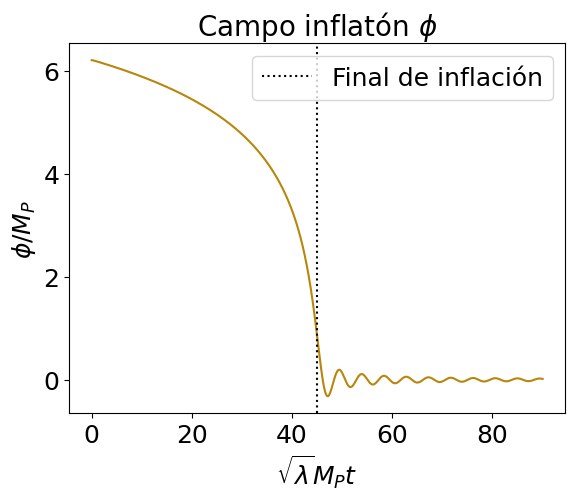

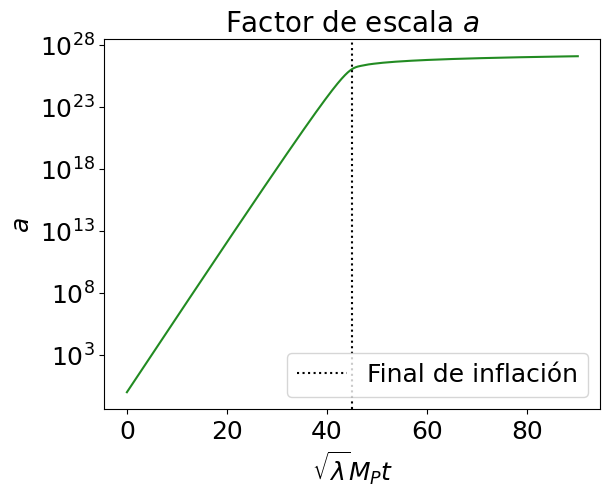

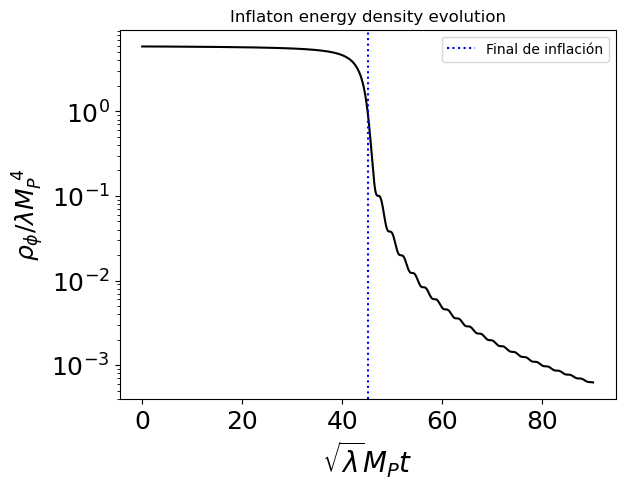

In [229]:
#plt.plot(t, comoving_horizon)
#plt.show()


plt.plot(t[t < t_end * 2], phi[t < t_end * 2], color = 'darkgoldenrod')
plt.xlabel(r'$\sqrt{\lambda} M_P t $', size = 18)
plt.ylabel(r'$ \phi / M_P$', size = 18)
plt.axvline(x = t_end, color = 'black', linestyle = 'dotted', label = 'Final de inflación')
plt.title(r'Campo inflatón $\phi$', size = 20)
# Change the font size of the x-axis tick labels
plt.tick_params(axis='x', labelsize=18) # Adjust labelsize as needed

# Change the font size of the y-axis tick labels
plt.tick_params(axis='y', labelsize=18) # Adjust labelsize as needed
plt.legend(fontsize = 18)
plt.show()



plt.plot(t[t < t_end * 2], a[t < t_end * 2], color = 'forestgreen')
plt.xlabel(r'$\sqrt{\lambda} M_P t $', size = 18)
plt.ylabel(r'$a$', size = 18)
plt.axvline(x = t_end, color = 'black', linestyle = 'dotted', label = 'Final de inflación')
plt.title(r'Factor de escala $a$', size = 20)
plt.yscale('log')
# Change the font size of the x-axis tick labels
plt.tick_params(axis='x', labelsize=18) # Adjust labelsize as needed

# Change the font size of the y-axis tick labels
plt.tick_params(axis='y', labelsize=18) # Adjust labelsize as needed
plt.legend(fontsize = 18)
plt.show()

rho_phi_array = np.array(rho_phi_tilde)

plt.plot(t[t < t_end * 2], rho_phi_array[t < t_end * 2], color = 'black')
plt.xlabel(r'$\sqrt{\lambda} M_P t $', size = 20)
plt.ylabel(r'$\rho_\phi/\lambda M_P^{\ 4}$', size = 18)
plt.axvline(x = t_end, color = 'blue', linestyle = 'dotted', label = 'Final de inflación')
plt.title(r'Inflaton energy density evolution')
# Change the font size of the x-axis tick labels
plt.tick_params(axis='x', labelsize=18) # Adjust labelsize as needed

# Change the font size of the y-axis tick labels
plt.tick_params(axis='y', labelsize=18) # Adjust labelsize as needed
plt.yscale('log')
plt.legend()
plt.show()


#plt.show()
#plt.plot(t, omega)
#plt.show()


#plt.plot(t, V)
#plt.plot(t, rho_phi)
#plt.show()


#plt.plot(t,a)
#plt.show()

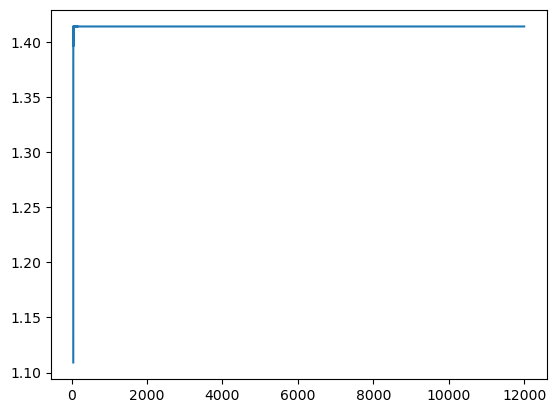

In [ ]:
plt.plot(t[t>t_end], m_phi_tilde[t>t_end] )
plt.show()


In [ ]:
' Interpolemos ahora las funciones importantes para este caso '

a_t = scipy.interpolate.interp1d(t, a)
t_a = scipy.interpolate.interp1d(a, t)


H_t = scipy.interpolate.interp1d(t, H)

rho_phi_tilde_t = scipy.interpolate.interp1d(t, rho_phi_tilde)

m_phi_tilde_t = scipy.interpolate.interp1d(t, m_phi_tilde)

phi_t = scipy.interpolate.interp1d(t, phi)

a_norm_t = scipy.interpolate.interp1d(t, a_norm)

t_a_norm = scipy.interpolate.interp1d(a_norm, t)

dphi_t = scipy.interpolate.interp1d(t, dphi)


In [ ]:
' Filtremos ahora los tiempos que están después de que acaba inflación '
t_filt = []
a_filt = []
H_filt = []
phi_filt = []
rho_phi_filt = []
a_filt_norm = []
m_phi_filt = []
a_norm_filt = []


for time_val, a_val, H_val, phi_val, rho_phi_val, m_phi_val, a_norm_val  in zip(t, a, H, phi, rho_phi_tilde, m_phi_tilde, a_norm):
    if time_val >= t_end:
        t_filt.append(time_val)
        a_filt.append(a_val)
        H_filt.append(H_val)
        phi_filt.append(phi_val)
        rho_phi_filt.append(rho_phi_val)
        a_filt_norm.append(a_val / a_end)
        m_phi_filt.append(m_phi_val)
        a_norm_filt.append(a_norm_val)      


## Ecuación de Boltzmann

## Término $ \delta\phi \rightarrow \chi\chi$

Tenemos la ecuación de Boltzmann 

$$\frac{\partial f_\chi}{\partial t}  - H p \frac{\partial f_\chi}{\partial p} = \frac{\pi \left|   \overline{\mathcal{M}} \right|^2}{2 m_\phi^{\ 2} \beta(t)} \delta\left(p - m_\phi \beta(t) \right),$$

donde 

$$ \beta(t) \equiv \sqrt{ 1 - \frac{m_{eff}^{\ 2}}{m_\phi^{\ 2}}  }, $$

con $ m_{eff}^{\ 2} = m_\chi^{\ 2} + \sigma \phi(t)^2 $. Se demuestra en el artículo arXiv:2206.08940v2 que

$$  \left| \overline{\mathcal{M}} \right|^2 = \frac{1}{8} \frac{\rho_\phi^{\ 2}}{m_\phi^{\ 4}} \hat{\sigma}^2, $$

con $ \hat{\sigma} \equiv \sigma - \lambda \left( 1 + \frac{m_{eff}^{\ 2}}{2 m_\phi^{\ 2}} \right) $. Haciendo la aproximación $m_{eff}<< m_\phi$, 

$$ \frac{\partial f_\chi}{\partial t}  - H p \frac{\partial f_\chi}{\partial p} = \frac{\pi}{2 m_\phi^{\ 2}} \frac{1}{8} \frac{\rho_\phi^{\ 2}}{m_\phi^{\ 4}} (\sigma - \lambda)^2 \delta\left(p - m_\phi \right) $$

## Momento comóvil

La ecuación integrada nos da

$$  f_\chi(t, q) = \frac{\pi}{16 m_\phi^{\ 7}} \lambda^2 ( k - 1 )^2 \frac{\rho_{\phi}^{\ 2}(t_0)}{H(t_0)} \ \theta(t_0 - t_{end}) \theta(t - t_0),  $$

donde 

$$\frac{q}{a(t_0)} = m_{\phi}$$


Adimencionalizando, finalmente se llega a que

$$ \frac{df_\chi}{dt} =   \frac{\pi}{16 \lambda^2} \cdot \frac{\rho^{\ 2}_\phi(t) \hat{\sigma}^2(t) }{N^{7/2}(t)}\cdot \frac{a(t)}{\bar{q} H(t)} \delta(t - t_0)$$

$$ \Rightarrow $$

$$ f_\chi (\bar{t}, \bar{q}) = \frac{\pi}{16 \lambda^2} \cdot \frac{\rho^{\ 2}_\phi(t_0) \hat{\sigma}^2(t_0) }{N^{7/2}(t_0)}\cdot \frac{a(t_0)}{\bar{q} H(t_0)} \theta(t_0 - t_{end}) \theta(t - t_0), $$

donde $t_0$ es tal que

$$\bar{q} = a(t_0)$$

y $\bar{q} \equiv q/m_\phi$, $\bar{t} \equiv \sqrt{\lambda} M_p t$. También, $N = V_{\varphi \varphi}$, $\varphi = \phi / M_p$.

In [ ]:
' Acoplamientos '
## PARA BOLTZMANN ##
# Bosones #
lambdaa = 2.5e-10
#sigma = 10e-7 # IMPORTANTE, AQUÍ ESTOY HACIENDO A SIGMA GORRO CTE
m_phi_reh = np.sqrt(2)




#rho_phi_tilde = np.array(rho_phi_tilde)
#m_phi_tilde = np.array(m_phi_tilde)

#rho_phi_bar = lambdaa * rho_phi_tilde
#m_phi_bar = np.sqrt(lambdaa) * m_phi_tilde

print(m_phi_tilde)
print(m_phi_tilde[-1])


[       nan        nan        nan ... 1.41421356 1.41421356 1.41421356]
1.4142135622190648


In [ ]:
'Discretizamos ahora al momento'
q_max = np.max(a_norm_filt)
q_min = np.min( a_norm_filt )
N_q = 200

q = np.linspace(q_min, q_max, N_q)

#print(q)


In [ ]:
' Encontemos primero a t_0 '
a_0 = q # a(t_0)

t_0 = t_a_norm(a_0) # t_0. t_a es la función t(a)

#print(t_0)


In [ ]:
#'  Ahora encontramos a f_chi para el decaimiento de phi a dos chis '
#prefactor = ( np.pi / ( 16*(m_phi**7) ) )  * (lambdaa**2) * ( ( alpha - 1 )**2 )



#prefactor = ( np.pi / ( 16 * (lambdaa**2)  ) ) * (sigma - lambdaa)**2


#rho_phi_t0_2 = rho_phi_tilde_t(t_0)**2

#H_t0 = H_t(t_0)

#f_t0 = prefactor * rho_phi_t0_2 * ( a_t(t_0) / ( q * H_t0 ) ) / ( m_phi_tilde_t(t_0) )**7

#f_chi = np.zeros((N_tiempo, N_q)) # iniciamos la función solución. Filas: tiempo, columnas: q#

#for i, time in enumerate(t_filt):
 #   for j in range(len(q)):
 #       if time >= t_0[j] and t_0[j] >= t_end:
 #           f_chi[i, j] = f_t0[j]
 #       else:
 #           f_chi[i, j] = 0.

#'Ahora, escalemos a la función de distribución por q^2'
#f_chi_qq = np.zeros((N_tiempo, N_q))

#for time_loop in range(len(t_filt)):
#    for q_loop in range(len(q)):
#        f_chi_qq[time_loop, q_loop] = (q[q_loop]**2) * f_chi[time_loop, q_loop] / (2 * np.pi**2)

## Término $\phi \rightarrow \chi\chi  + \chi \chi \rightarrow  \psi \psi$

El término a añadir es

$$ \mathcal{C}[f_\chi] = - \frac{\sigma y^2 \phi^2}{8(2\pi)^2 p^2}f_\chi(t,p) \int_0^{m_\phi} \frac{dp'}{p'} f_\chi(t,p') \times \left\{   \frac{m_\phi}{\Gamma_\phi} \left[  a \cot{\left(   \frac{\Gamma_\phi}{m_\phi} \right) } - a\cot{  \left( \frac{m_\phi \Gamma_\phi}{m_\phi^{\ 2 } - 4pp' } \right)  }  \right] +  \frac{1}{2} \left[ \frac{ (m_\phi^{\ 2} - 4pp')^2 + m_\phi^{\ 2}\Gamma_\phi^{\ 2} }{m_\phi^{\ 2} (m_\phi^{\ 2} + \Gamma_\phi^{\ 2})  } \right]  \right\} $$

Si adimencionalizamos, tenemos 

$$  \frac{df_\chi}{d\bar{t}} = \frac{\pi}{16\lambda^2} \cdot \frac{\rho_\phi (\bar{t})^2 (\sigma - \lambda)^2}{N(\bar{t})^{7/2}}\cdot \frac{a(\bar{t})}{\bar{q} H(\bar{t})}\delta( \bar{t} - t_0 )  - \frac{\sigma^2 y^2}{8 (2\pi)^3}  \cdot \frac{1}{\lambda \sqrt{N}} \cdot \frac{\varphi^2}{\bar{q^2}} a(\bar{t}) \cdot f_\chi(\bar{t}, \bar{q}) \int_0^{\bar{q}_{max} / a(\bar{t})} d\bar{q'} \ f_\chi(\bar{t}, \bar{q'}) \cdot g(\bar{t}, \bar{q}, \bar{q'} ), $$

donde 

$$ g(\bar{t}, \bar{q}, \bar{q'}) =   \frac{1}{\Gamma_\phi'}\left[   \arctan{\left(   \frac{\Gamma_\phi'}{1 - 4\bar{q}\bar{q'}/a^2(\bar{t})}  \right)} - \arctan{\left(  \Gamma_\phi'  \right)}  \right]  + \frac{1}{2} \ln{ \left[  \frac{ ( 1 - 4\bar{q}\bar{q'}/a^2(\bar{t}) )^{2} + \Gamma_\phi'^{\ 2} }{1 + \Gamma_\phi'^{\ 2}}  \right]}    $$

y $t_0$ es tal que

$$ \bar{q} = a(t_0). $$

Las constantes están dadas por $ \Gamma_\phi' = \Gamma_\phi/m_\phi = \frac{y^2}{8\pi} $. 

Si integramos de $\bar{t}_{end}$ a $\bar{t}$, llegamos a que


$$ f_{\chi}(\bar{t}, \hat{q} ) =  \frac{\pi}{16\lambda^2}\cdot \frac{\rho_\phi(t_0)^2 \hat{\sigma}^2(t_0)}{N(t_0)^{7/2}} \cdot \frac{\hat{a}(t_0)}{\hat{q}H(t_0)} \theta(t_0 - t_{end})\theta(\bar{t} - t_0) - \frac{\sigma^2 y^2}{8 (2\pi)^3}\cdot \frac{1}{\lambda \hat{q}^2}\int_{t_{end}}^{\bar{t}}dt' \frac{\varphi(t')^2 \hat{a}(t') }{\sqrt{N(t')}} f_{\chi}(t', \hat{q}) \int_0^{q_{max}} d\hat{q}' f_\chi(t', \hat{q}') g(t', \hat{q}, \hat{q}'),$$

con 


$$  g(\bar{t}, \hat{q}, q') =   \frac{1}{\Gamma_\phi'}\left[   \arctan{\left(   \frac{\Gamma_\phi'}{1 - 4\hat{q}\hat{q}'/\hat{a}^2(\bar{t})}  \right)} - \arctan{\left(  \Gamma_\phi'  \right)}  \right]  + \frac{1}{2} \ln{ \left[  \frac{ ( 1 - 4\hat{q}\hat{q}'/\hat{a}^2(\bar{t}) )^{2} + \Gamma_\phi'^{\ 2} }{1 + \Gamma_\phi'^{\ 2}}  \right]},    $$

donde $ \hat{q} = q/(a_{end}m_\phi) $, $\hat{a} = a / a_{end}$ y $t_0$ es tal que 


$$ \hat{q} = \hat{a}(t_0).  $$

$$ f_\chi(t, q) = \frac{\pi}{16 \lambda^2} \cdot \frac{\hat{\sigma}(t_0)}{\beta(t_0)} \cdot \frac{1}{\left| \beta(t_0) H(t_0) + \beta'(t_0)  \right|} \cdot \frac{\rho_\phi^{\ 2}}{m_\phi^7} \theta(t_0 - t_{end})\theta(t - t_0) $$

con $t_0$ tal que

$$  q = a(t_0) \beta(t_0)  $$

Durante este periodo, la dinámica está dada por

$$\dot{\rho_\phi} + 3 H\rho_\phi + \Gamma_\phi \rho_\phi = 0$$
$$  \dot{\rho_\psi} + 4 H\rho_\psi - \Gamma_\phi = 0$$
$$  \rho_\phi + \rho_\psi = 3H^2 M_P^{\ 2}  $$

O bien, usando $\bar{t} = \sqrt{\lambda} M_P t$, tenemos que

In [152]:
def H_reh(rho_phi, rho_psi):
    total_rho = rho_phi + rho_psi
    total_rho = np.maximum(total_rho, 1e-30)
    return np.sqrt( (1/3) * total_rho)


def reheating_system(x, y_sol, y):
    rho_phi_reh, rho_psi_reh, a_reh = y_sol

    rho_phi_reh = max(rho_phi_reh, 0.0)
    rho_psi_reh = max(rho_psi_reh, 0.0)
    a_reh = max(a_reh, a_end)

    H_value = H_reh(rho_phi_reh, rho_psi_reh)
    Gamma = (y**2 / (8 * np.pi))
    m_phi_value = np.sqrt(2)

    drho_phi_dt = - (3 * H_value + Gamma * m_phi_value  ) * rho_phi_reh

    drho_psi_dt = - 4 * (H_value * rho_psi_reh)  +   (Gamma * m_phi_value * rho_phi_reh)

    da_dt = a_reh * H_value

    return np.array([drho_phi_dt, drho_psi_dt, da_dt])

def solve_reh_system(y, a, b, N_reh_T, yinits):
    def system(x, y_sol):
        return reheating_system(x, y_sol, y)
    
    t_reh, solution = rk4(system, a, b, N_reh_T, yinits)

    rho_phi_reh = solution[:, 0]
    rho_psi_reh = solution[:, 1]
    a_reh = solution[:, 2]  

    H_reheat = H_reh(rho_phi_reh, rho_psi_reh)

    a_norm_reh_t = scipy.interpolate.interp1d(t_reh, a_reh/a_end)

    rho_phi_reh_t = scipy.interpolate.interp1d(t_reh, rho_phi_reh)

    rho_psi_reh_t = scipy.interpolate.interp1d(t_reh, rho_psi_reh)
    

    return t_reh, rho_phi_reh, rho_psi_reh, a_reh, H_reheat, [a_norm_reh_t, rho_phi_reh_t, rho_psi_reh_t]

#yinits = np.array([rho_phi_tilde_end, 0., a_end])
#sol = solve_reh_system(1e-6, t_end, t_max, 1000, yinits)
print(rho_phi_tilde_end, m_phi_tilde[-1], a_end)





0.9666378785642813 1.4142135622190648 1.1265775185754563e+26


In [ ]:
'Definimos a algunas funciones auxiliares'
def beta(t, m_chi, lambdaa, sigma):
    term = 1 - ( m_chi / m_phi_reh )**2 - ((sigma / lambdaa))*(phi_t(t)/ m_phi_reh )**2
    return np.sqrt(term)

def beta_der(t, m_chi, lambdaa, sigma):
    factor1 = - (dphi_t(t)* phi_t(t))/(m_phi_reh**2)
    factor2 = (1 - ( m_chi / m_phi_reh )**2 - ((sigma / lambdaa)**2)*(phi_t(t)/ m_phi_reh )**2)**(-1/2)
    return factor1*factor2

def sigma_hat(t, m_chi, lambdaa, sigma):
    factor = 1 + (1/2)*(m_chi / m_phi_reh)**2 + (1/2)*( phi_t(t)/ m_phi_reh )**2
    return sigma - lambdaa*factor

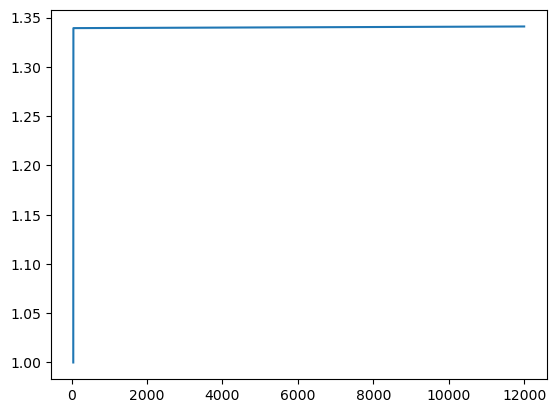

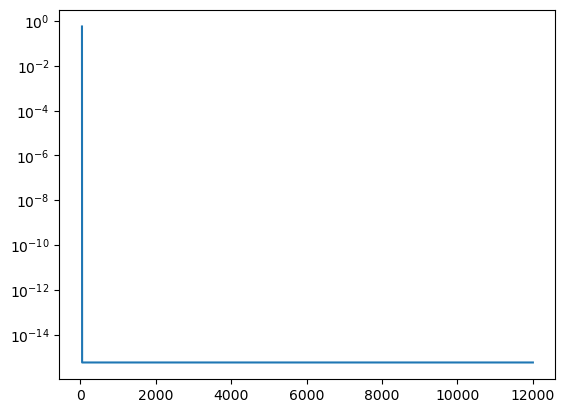

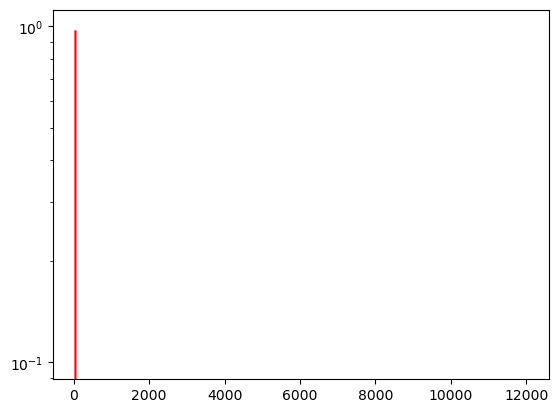

In [ ]:
yinits = np.array([rho_phi_tilde_end, 0., a_end])
sol = solve_reh_system(1e-6, t_end, t_max, 10000, yinits)

a_reh = sol[3]
H_reh_sol = sol[4]
rho_phi_reh = sol[1]

t_reh = sol[0]

plt.plot(t_reh, (a_reh/a_end))
#plt.yscale('log')
plt.show()

plt.plot(t_reh, H_reh_sol)
plt.yscale('log')
plt.show()

plt.plot(t_reh, rho_phi_reh, color = 'red')
plt.plot()
plt.yscale('log')
plt.show()

In [ ]:
'Redefinimos la malla'
#q_min = np.min(a_norm_filt) #Tengo que ver si conviene este q_min

#q2_min = np.min(a_norm_filt)

#q2_max = np.max(a_norm_filt) #Tengo que ver si conviene este q_max
#N2_q = 1000

#q2 = np.linspace(q2_min, q2_max, N2_q)



#rho_phi_avaraged_t = scipy.interpolate.interp1d(t, rho_phi_avaraged)

#q2 = np.array(q2)


#t_00 = t_a_norm(q2) # Esto es t_0. El doble cero viene para diferenciarlo del t_0 del caso anterior

# Acoplamiento Yukawa (ya es adimensional):

#y = 1e-6 ##

# Razón de decaimiento adimensionalizada
#Gamma = (y**2 / (8*np.pi))

'Redefinimos la malla'

In [ ]:
# Debemos definir algunas funciones
# Primero, el 1er término es:

def termino1(t, m_chi, lambdaa, sigma, y):
    idx_start = np.argmin(np.abs(t - t_end))
    idx_end = np.argmin(np.abs(t - t_max))


    t_submesh = t[idx_start:idx_end+1]
    N_reh_T = len(t_submesh)*10

    #N_reh_T = int(math.ceil(t_max - t_end)*1.5)
    yinits = np.array([rho_phi_tilde_end, 0., a_end])
    solution = solve_reh_system(y, t_end, t_max, N_reh_T, yinits)
    t_reh, rho_phi_reh, rho_psi_reh, a_reh, H_reh_array = solution[0], solution[1], solution[2], solution[3], solution[4] 

    a_reh_norm = a_reh / a_end

    rho_phi_reh_t = scipy.interpolate.interp1d(t_reh, rho_phi_reh)
    H_reh_t = scipy.interpolate.interp1d(t_reh, H_reh_array)
    a_reh_t = scipy.interpolate.interp1d(t_reh, a_reh)
    a_reh_norm_t = scipy.interpolate.interp1d(t_reh, a_reh/a_end)
    t_a_reh = scipy.interpolate.interp1d(a_reh, t_reh)
    t_a_reh_norm = scipy.interpolate.interp1d(a_reh/a_end, t_reh)


    # Ahora encontramos a beta

    beta_array = beta(t_reh, m_chi, lambdaa, sigma)

    a_beta_array = beta_array * a_reh_norm

    a_beta_t = scipy.interpolate.interp1d(t_reh, a_beta_array)
    t_beta_a = scipy.interpolate.interp1d(a_beta_array, t_reh)
    
    q_min =  np.min(a_beta_array)
    q_max = np.max(a_beta_array)

    N_q = 1000

    q = np.linspace(q_min, q_max, N_q)


    t_0 = t_beta_a(q)




    resultado = np.zeros((len(t), len(q)))
    #Gamma = y**2/(8 * np.pi) * m_phi_reh
    
    prefac1 = (np.pi/(16*lambdaa**2))



    with tqdm(total = len(t), desc ='Procesando') as pbar:
        for i, t_val in enumerate(t):
            for j, q_val in enumerate(q):
                t_0_val = t_0[j]

                if t_val < t_end:
                    pass
                elif t_0_val >= t_end and t_0_val <= t_val:
                    prefac2 = sigma_hat(t_0_val, m_chi, lambdaa, sigma)**2 
                    prefac3 = 1 / beta(t_0_val, m_chi, lambdaa, sigma)
                    prefac4 = 1 / np.abs( beta(t_0_val, m_chi, lambdaa, sigma) * H_reh_t(t_0_val)  + beta_der(t_0_val, m_chi, lambdaa, sigma)  )
                    prefac5 = ( (rho_phi_reh_t(t_0_val)**2)/m_phi_reh**7  )
                    resultado[i, j] = prefac1 * prefac2 * prefac3 * prefac4 * prefac5
                else:
                    pass
            pbar.update(1)
            pbar.set_postfix({'Completado': f'{i+1}/{len(t)}'})

    return resultado, q


#def arccot(x):
#    return np.arctan(1/x)


# El integrando es el siguiente. q1 es q', la variable de integración.

def g(t_index, q, q1, y):
    Gamma = (y**2 / (8*np.pi))
    return (1 / Gamma) * (    np.arctan((Gamma) / (  1 - 4*( q*q1 /a_norm[t_index]**2 )   ))   - np.arctan(Gamma) ) + (1 / 2) * np.log(  ((1 - 4*( q*q1 / (a_norm[t_index]**2) ) )**2 + Gamma**2)  / (1 + Gamma**2)  )




# La solución está dada por

def correccion(t, q, sigma, y):
    N_tiempo = len(t) # Número de nodos en la malla de tiempo
    N2_q = len(q) # Número de nodos en la malla de momento comóvil


    resultado = np.zeros((N_tiempo, N2_q)) # Creamos la solución como una matriz de ceros. Las filas son el tiempo y las columnas moemnto comóvil


    prefac2 = - ( ( (sigma**2)*(y**2) ) / (8* lambdaa *(2*np.pi)**3)  ) # El prefactor del término 2

    
    def closest(list, target):
        return min(list, key = lambda x: abs(x - target))
    
    t_end_c = closest(t, t_end) 

    term1 = termino1(t, q, sigma, y) # Se calcula el 1er término

    with tqdm(total = len(t), desc ='Procesando') as pbar: 
        for i, t_val in enumerate(t): # Fijamos un tiempo de la función f_chi
            if t_val < t_end_c: # 
                pbar.update(1)
                continue # No se hace nada si el t < t_end
            
            t_int = t[(t >= t_end) & (t <= t_val)] # Este es el tiempo de integración
            t_int_index = np.where((t >= t_end) & (t <= t_val))[0] # Estos son los índices de integración

            for j, q_val in enumerate(q):
                

                if t_val == t_end_c: # Si t = t_end, se toma el primer término sólamente para el valor de f_chi
                    resultado[i, j] = term1[i, j] # Sólo se toma el primer valor

                elif t_val > t_end: # Para t > t_end 
                    

                    integrando_t_array = np.zeros(len(t_int)) # Definimos el valor del integrando en la int dt'


                    for k, t_index_val in enumerate(t_int_index): # Para los índices del integrando, k es el índice de el numeramiento actual
                                                                  # y t_index_val el valor del índice de los t_int
                                                                  # Básicamente, si se evalúa una lista temporal en t_index_val, se tiene
                                                                  # el valor asociado a ese tiempo
                        t_val_int = t[t_index_val] # El valor actual del tiempo


                        qp_max = q.max() # Este es el límite superior de la integral dq'
                        
                        qp_index = np.where((q >= 0 ) & (q <= qp_max))[0] # Son los índices que están en nuestra malla q que están dentro 
                                                                          # de los límites de integración 

                        
                        
                        f_qprime = resultado[t_index_val, qp_index] # Se toma el valor anteriormente calculado

                        g_vals = g(t_index_val, q_val, q[qp_index], y) # El valor de la función g del integrando en dq' 

                        integrando_q = f_qprime * g_vals # El valor del integrando en dq'

                        integral_q = np.trapz(integrando_q, q[qp_index]) # Se realiza la integral dq'

                        f_tprime = resultado[t_index_val, j] # Calcula el valor de la función f_chi al tiempo t_index_val de la integral dt'


                        integrando_t_array[k] = (a_norm[t_index_val] * (phi[t_index_val]**2) / m_phi[t_index_val] ) * f_tprime * integral_q # Añade al array del
                                                                                                                                            # integrando en dt'





                    
                    if len(t_int_index) > 1:
                        integral_t = np.trapz(integrando_t_array, t[t_int_index]) # Realiza la integral dt'
                    else:
                        integral_t = 0.


                    termino2 = prefac2 * integral_t * (1 / q_val**2) # El valor del segundo término a los valores t y q fijos

                    resultado[i, j] = term1[i, j] + termino2 # Añade el valor a este array
            pbar.update(1)
            pbar.set_postfix({'Completado': f'{i+1}/{len(t)}'})
        
        #print(f'Progreso: {i+1}/{len(t)} ', end='\r')

    return resultado





def soloi(m_chi, sigma, y):
    return termino1(t, m_chi, lambdaa, sigma, y)

#def sol3ij(sigma, y):
#    return correccion(t, sigma, y)

In [ ]:
#test_solo1 = soloi(0.0001 * m_phi_reh,(10**1)*lambdaa, 10**(-5))
#test_solo2 = soloi((10**4)*lambdaa, 10**(-6))
#test_solo3 = soloi((10**4)*lambdaa, 10**(-7))
#test_solo4 = soloi((10**4)*lambdaa, 10**(-8))

#print(test_solo1)



#plt.figure(figsize = (14, 12))
#p = -1
#p2 = -100
#plt.plot(q2, (q2**2)*test_corrección[p, :], color = 'black', label = rf'Solución corregida. $\sigma = ${1}')
#plt.plot(test_solo1[1], (test_solo1[1]**2) * test_solo1[0][p, :]/(2*np.pi**2), color = 'black', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[p]:.2f}, $y = 0$, $\sigma = 10^{{1}}\lambda$')
#plt.plot(q2, (q2**2) * test_solo1[p2, :], color = 'black', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[p2]:.2f}, $y = 0$, $\sigma = 10^{{1}}\lambda$')
#plt.plot(q2, (q2**2) * test_solo2[p, :]/(2*np.pi**2), color = 'red', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[p]:.2f}, $y = 0$, $\sigma = 10^{{2}}\lambda$')
#plt.plot(q2, (q2**2) * test_solo3[p, :]/(2*np.pi**2), color = 'blue', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[p]:.2f}, $y = 0$, $\sigma = 10^{{3}}\lambda$')
#plt.plot(q2, (q2**2) * test_solo4[p, :]/(2*np.pi**2), color = 'orange', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[p]:.2f}, $y = 0$, $\sigma = 10^{{4}}\lambda$')
#plt.plot()
#plt.plot(q2, (q2**2) * test_solo[500, :], color = 'blue', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[500]:.2f}')
#plt.title(rf'Phase space distribution $f_\chi$')
#plt.xlabel(r'$ \frac{q}{a_{end} m_\phi} $', size = 16)
#plt.ylabel(r'$ (\frac{q}{a_{end} m_\phi})^2 f_\chi$', size = 16)
#plt.legend()
#plt.grid()
#plt.yscale('log')
#plt.xscale('log')

#plt.savefig('comparacion.png')
#plt.show()
##print(a_norm_filt[-1])
#print(test_solo1)
#print(test_corrección)

In [ ]:
# Debemos definir algunas funciones
# Primero, el 1er término es:

def termino1_2(t, N_q, lambdaa, sigma, y):
    idx_start = np.argmin(np.abs(t - t_end))
    idx_end = np.argmin(np.abs(t - t_max))


    t_submesh = t[idx_start:idx_end+1]
    N_reh_T = len(t_submesh)

    #N_reh_T = int(math.ceil(t_max - t_end)*1.5)
    yinits = np.array([rho_phi_tilde_end, 0., a_end])
    solution = solve_reh_system(y, t_end, t_max, N_reh_T, yinits)
    t_reh, rho_phi_reh, rho_psi_reh, a_reh, H_reh_array = solution[0], solution[1], solution[2], solution[3], solution[4] 

    a_reh_norm = a_reh / a_end

    rho_phi_reh_t = scipy.interpolate.interp1d(t_reh, rho_phi_reh)
    H_reh_t = scipy.interpolate.interp1d(t_reh, H_reh_array)
    a_reh_t = scipy.interpolate.interp1d(t_reh, a_reh)
    a_reh_norm_t = scipy.interpolate.interp1d(t_reh, a_reh/a_end)
    t_a_reh = scipy.interpolate.interp1d(a_reh, t_reh)
    t_a_reh_norm = scipy.interpolate.interp1d(a_reh/a_end, t_reh)

    rho_psi_reh_t = scipy.interpolate.interp1d(t_reh, rho_psi_reh)


    # Ahora encontramos a beta

    


    
    q_min =  np.min(a_reh/a_end)
    q_max = np.max(a_reh/a_end)

    q = np.linspace(q_min, q_max, N_q)


    t_0 = t_a_reh_norm(q)




    resultado = np.zeros((len(t), len(q)))
    #Gamma = y**2/(8 * np.pi) * m_phi_reh
    
    prefac1 = (np.pi/(16*lambdaa**2))



    with tqdm(total = len(t), desc ='Procesando') as pbar:
        for i, t_val in enumerate(t):
            for j, q_val in enumerate(q):
                t_0_val = t_0[j]

                if t_val < t_end:
                    pass
                elif t_0_val >= t_end and t_0_val <= t_val:
                    prefac2 = (sigma - lambdaa)**2
                    prefac3 = 1 
                    prefac4 = 1 / np.abs( H_reh_t(t_0_val)  )
                    prefac5 = ( (rho_phi_reh_t(t_0_val)**2)/m_phi_reh**7  )
                    resultado[i, j] = prefac1 * prefac2 * prefac3 * prefac4 * prefac5
                else:
                    pass
            pbar.update(1)
            pbar.set_postfix({'Completado': f'{i+1}/{len(t)}'})

    return resultado, q, [a_reh, a_reh_t], [a_reh_norm, a_reh_norm_t], [H_reh_array, H_reh_t], [rho_phi_reh, rho_phi_reh_t], [rho_psi_reh, rho_psi_reh_t]


#def arccot(x):
#    return np.arctan(1/x)

##############################################################################################################################################################################
##############################################################################################################################################################################
# El integrando es el siguiente. q1 es q', la variable de integración.

def g(t_index, q, q1, y):
    Gamma = (y**2 / (8*np.pi))
    return (1 / Gamma) * (    np.arctan((Gamma) / (  1 - 4*( q*q1 /a_norm[t_index]**2 )   ))   - np.arctan(Gamma) ) + (1 / 2) * np.log(  ((1 - 4*( q*q1 / (a_norm[t_index]**2) ) )**2 + Gamma**2)  / (1 + Gamma**2)  )



##############################################################################################################################################################################
##############################################################################################################################################################################
# La solución está dada por

def correccion(t, N_q, lambdaa, sigma, y):
    N_tiempo = len(t) # Número de nodos en la malla de tiempo


    resultado = np.zeros((N_tiempo, N_q)) # Creamos la solución como una matriz de ceros. Las filas son el tiempo y las columnas moemnto comóvil


    prefac2 = - ( ( (sigma**2)*(y**2) ) / (8* lambdaa *(2*np.pi)**3)  ) # El prefactor del término 2

    
    def closest(list, target):
        return min(list, key = lambda x: abs(x - target))
    
    t_end_c = closest(t, t_end) 

    resultado1 = termino1_2(t, N_q, lambdaa, sigma, y)
    term1 = resultado1[0] # Se calcula el 1er término
    
    q = resultado1[1]

    a_norm_reh_t = resultado[3][1]

    H_reh_t = resultado[4][1]

    rho_phi_reh_t = resultado[5][1]

    m_phi_reh = np.sqrt(2)

    with tqdm(total = len(t), desc ='Procesando') as pbar: 
        for i, t_val in enumerate(t): # Fijamos un tiempo de la función f_chi
            if t_val < t_end_c: # 
                pbar.update(1)
                continue # No se hace nada si el t < t_end
            
            t_int = t[(t >= t_end) & (t <= t_val)] # Este es el tiempo de integración
            t_int_index = np.where((t >= t_end) & (t <= t_val))[0] # Estos son los índices de integración

            for j, q_val in enumerate(q):
                

                if t_val == t_end_c: # Si t = t_end, se toma el primer término sólamente para el valor de f_chi
                    resultado[i, j] = term1[i, j] # Sólo se toma el primer valor

                elif t_val > t_end: # Para t > t_end 
                    

                    integrando_t_array = np.zeros(len(t_int)) # Definimos el valor del integrando en la int dt'


                    for k, t_int_val in enumerate(t_int): # Los tiempos del integrando


                        qp_max = q.max() # Este es el límite superior de la integral dq'
                        
                        qp_index = np.where((q >= 0 ) & (q <= qp_max))[0] # Son los índices que están en nuestra malla q que están dentro 
                                                                          # de los límites de integración 

                        
                        
                        f_qprime = resultado[t_index_val, qp_index] # Se toma el valor anteriormente calculado

                        g_vals = g(t_index_val, q_val, q[qp_index], y) # El valor de la función g del integrando en dq' 

                        integrando_q = f_qprime * g_vals # El valor del integrando en dq'

                        integral_q = np.trapz(integrando_q, q[qp_index]) # Se realiza la integral dq'

                        f_tprime = resultado[t_index_val, j] # Calcula el valor de la función f_chi al tiempo t_index_val de la integral dt'


                        integrando_t_array[k] = (a_norm_reh_t(t_int_val) * (phi_t(t_int_val)**2) / m_phi_reh) * f_tprime * integral_q # Añade al array del
                                                                                                                                            # integrando en dt'





                    
                    if len(t_int_index) > 1:
                        integral_t = np.trapz(integrando_t_array, t[t_int_index]) # Realiza la integral dt'
                    else:
                        integral_t = 0.


                    termino2 = prefac2 * integral_t * (1 / q_val**2) # El valor del segundo término a los valores t y q fijos

                    resultado[i, j] = term1[i, j] + termino2 # Añade el valor a este array
            pbar.update(1)
            pbar.set_postfix({'Completado': f'{i+1}/{len(t)}'})
        
        #print(f'Progreso: {i+1}/{len(t)} ', end='\r')

    return resultado




t_nuevo = np.linspace(t_min, t_max, int(np.ceil(int(t_max)*3)))
t_nuevo = np.array(t_nuevo)

def soloi(m_chi, sigma, y):
    return termino1_2(t_nuevo, m_chi, lambdaa, sigma, y)
    
#def sol3ij(sigma, y):
#    return correccion(t, sigma, y)

In [255]:
# Código para calcular temperatura de reh

def temperatura_reh(N_reh_T, t_max, sigma, y):


    yinits = np.array([rho_phi_tilde_end, 0., a_end])
    resultado = solve_reh_system(y, t_end, t_max, N_reh_T, yinits)

    a_norm_reh_t = resultado[5][0]
    rho_phi_reh_t = resultado[5][1]
    rho_psi_reh_t = resultado[5][2]
    
    def diferencia_rho(x):
        return rho_phi_reh_t(x) - rho_psi_reh_t(x)

    for i, t_val_reh in enumerate(t[t >= t_end]):
        if diferencia_rho(t_val_reh) <= 0:
            t_reh_final = t_val_reh
            print('Se encontró final del recalentamiento')
            break
    else:
        print('No se llega al final del recalentamiento en este intervalo de tiempo')

    # La densidad de energía al final de recalentamiento es 

    rho_reh_end = rho_psi_reh_t(t_reh_final)

    # El factor de escala normalizado al final de recalentamiento es 

    a_norm_reh_end = a_norm_reh_t(t_reh_final)

    # La temperatura entonces será 
    T_reh = (  (30*rho_reh_end) / (106.75*np.pi**2)  )**(1/4)

    T_reh_GeV = T_reh * 2.4e18

    return T_reh_GeV, t_reh_final

def m_chi_func(N_reh_T, t_max, sigma, y, temp_function):
    resultado = temp_function(N_reh_T, t_max, sigma, y)
    T_reh_GeV = resultado[0]
    t_reh_final = resultado[1]
    Omega_h2 = 0.12
    prefactor1 = ( 2.05e-11 / lambdaa )**(1/2)
    prefactor2 = (lambdaa / ( sigma - lambdaa ))**2
    T_reh_norm = ( (10**10) / T_reh_GeV)

    return prefactor1 * prefactor2* T_reh_norm * (7e6), T_reh_GeV, t_reh_final # El último factor hace que tengamos la masa en GeV











In [219]:
#t_nuevo_2 = np.linspace(t_min, t_max, int(np.ceil(  t_max*4  )))
#t_nuevo_2 = np.array(t_nuevo_2)
sigma_10 = 10*lambdaa
y_array = np.logspace(-1, -4, 10)
m_chi_array = np.array([[0.0, 0.0, 0.0, 0.0]] * len(y_array))

#print(y_array)
t_max_reh = 2000
N_reh_t = t_max_reh


for i, y_val in enumerate(y_array):
    print('######################################################################')
    print(rf'({i + 1}/{len(y_array)}) Empezando cálculo de m_chi en GeV para y = {y_val}')
    
    resultado = m_chi_func(N_reh_t, t_max_reh, sigma_10, y_val, temperatura_reh)
    T_reh_GeV = resultado[1]
    m_chi_val = resultado[0]
    t_reh_final = resultado[2]
    
    m_chi_array[i][0] = m_chi_val
    m_chi_array[i][1] = T_reh_GeV
    m_chi_array[i][2] = y_val
    m_chi_array[i][3] = t_reh_final
    
    t_max_reh = t_max_reh * 5
    
    N_reh_t = int(np.ceil(t_max_reh))
    
    print(f'm_chi = {m_chi_array[i][0]}, T_reh = {m_chi_array[i][1]}, t_reh_final = {m_chi_array[i][3]}')
    print(f'Próximo t_max_reh = {t_max_reh}')
    print('Corrida guardada correctamente')



######################################################################
(1/10) Empezando cálculo de m_chi en GeV para y = 0.1


Procesando RK4: 100%|██████████| 2000/2000 [00:01<00:00, 1350.07it/s, Completado=1/2000]


Se encontró final del recalentamiento
m_chi = 0.01255404221242021, T_reh = 1.971225745600458e+16, t_reh_final = 1916.0219160219162
Próximo t_max_reh = 10000
Corrida guardada correctamente
######################################################################
(2/10) Empezando cálculo de m_chi en GeV para y = 0.046415888336127795


Procesando RK4: 100%|██████████| 10000/10000 [00:07<00:00, 1310.59it/s, Completado=2/10000]


Se encontró final del recalentamiento
m_chi = 0.027046933696422092, T_reh = 9149595846331110.0, t_reh_final = 8735.768735768737
Próximo t_max_reh = 50000
Corrida guardada correctamente
######################################################################
(3/10) Empezando cálculo de m_chi en GeV para y = 0.021544346900318846


Procesando RK4: 100%|██████████| 50000/50000 [00:57<00:00, 866.13it/s, Completado=3/50000] 


No se llega al final del recalentamiento en este intervalo de tiempo


UnboundLocalError: cannot access local variable 't_reh_final' where it is not associated with a value

In [ ]:
t_max_reh = 2000
resultado1 = m_chi_func(t_max_reh, 2000, 10*lambdaa, 1e-1, temperatura_reh)


Procesando RK4: 100%|██████████| 2000/2000 [00:01<00:00, 1227.50it/s, Completado=3/2000]


Se encontró final del recalentamiento


Procesando RK4: 100%|██████████| 60000/60000 [01:09<00:00, 866.85it/s, Completado=3/60000] 


ValueError: A value (2000.0020000020002) in x_new is above the interpolation range's maximum value (2000.0).

In [ ]:
#t_nuevo_2 = np.linspace(t_min, t_max, int(np.ceil(  t_max*4  )))
#t_nuevo_2 = np.array(t_nuevo_2)
sigma_10 = 5*lambdaa
y_array = np.logspace(-1, -6, 20)
m_chi_array5 = np.array([[0.0, 0.0, 0.0, 0.0]] * len(y_array))
t_max_reh = 50000
N_reh_t = t_max_reh*2
#print(y_array)



for i, y_val in enumerate(y_array):
    print('######################################################################')
    print(rf'({i + 1}/{len(y_array)}) Empezando cálculo de m_chi en GeV para y = {y_val}')
    resultado = m_chi_func(N_reh_t, t_max_reh, sigma_10, y_val, temperatura_reh)
    T_reh_GeV = resultado[1]
    m_chi_val = resultado[0]
    t_reh_final = resultado[2]
    m_chi_array[i][0] = m_chi_val
    m_chi_array[i][1] = T_reh_GeV
    m_chi_array[i][2] = y_val
    m_chi_array[i][3] = t_reh_final
    print(f'm_chi = {m_chi_array[i][0]}, T_reh = {m_chi_array[i][1]}, t_reh_final = {m_chi_array[i][3]}')
#    print(m_chi_array[i])
    print('Corrida guardada correctamente')

    

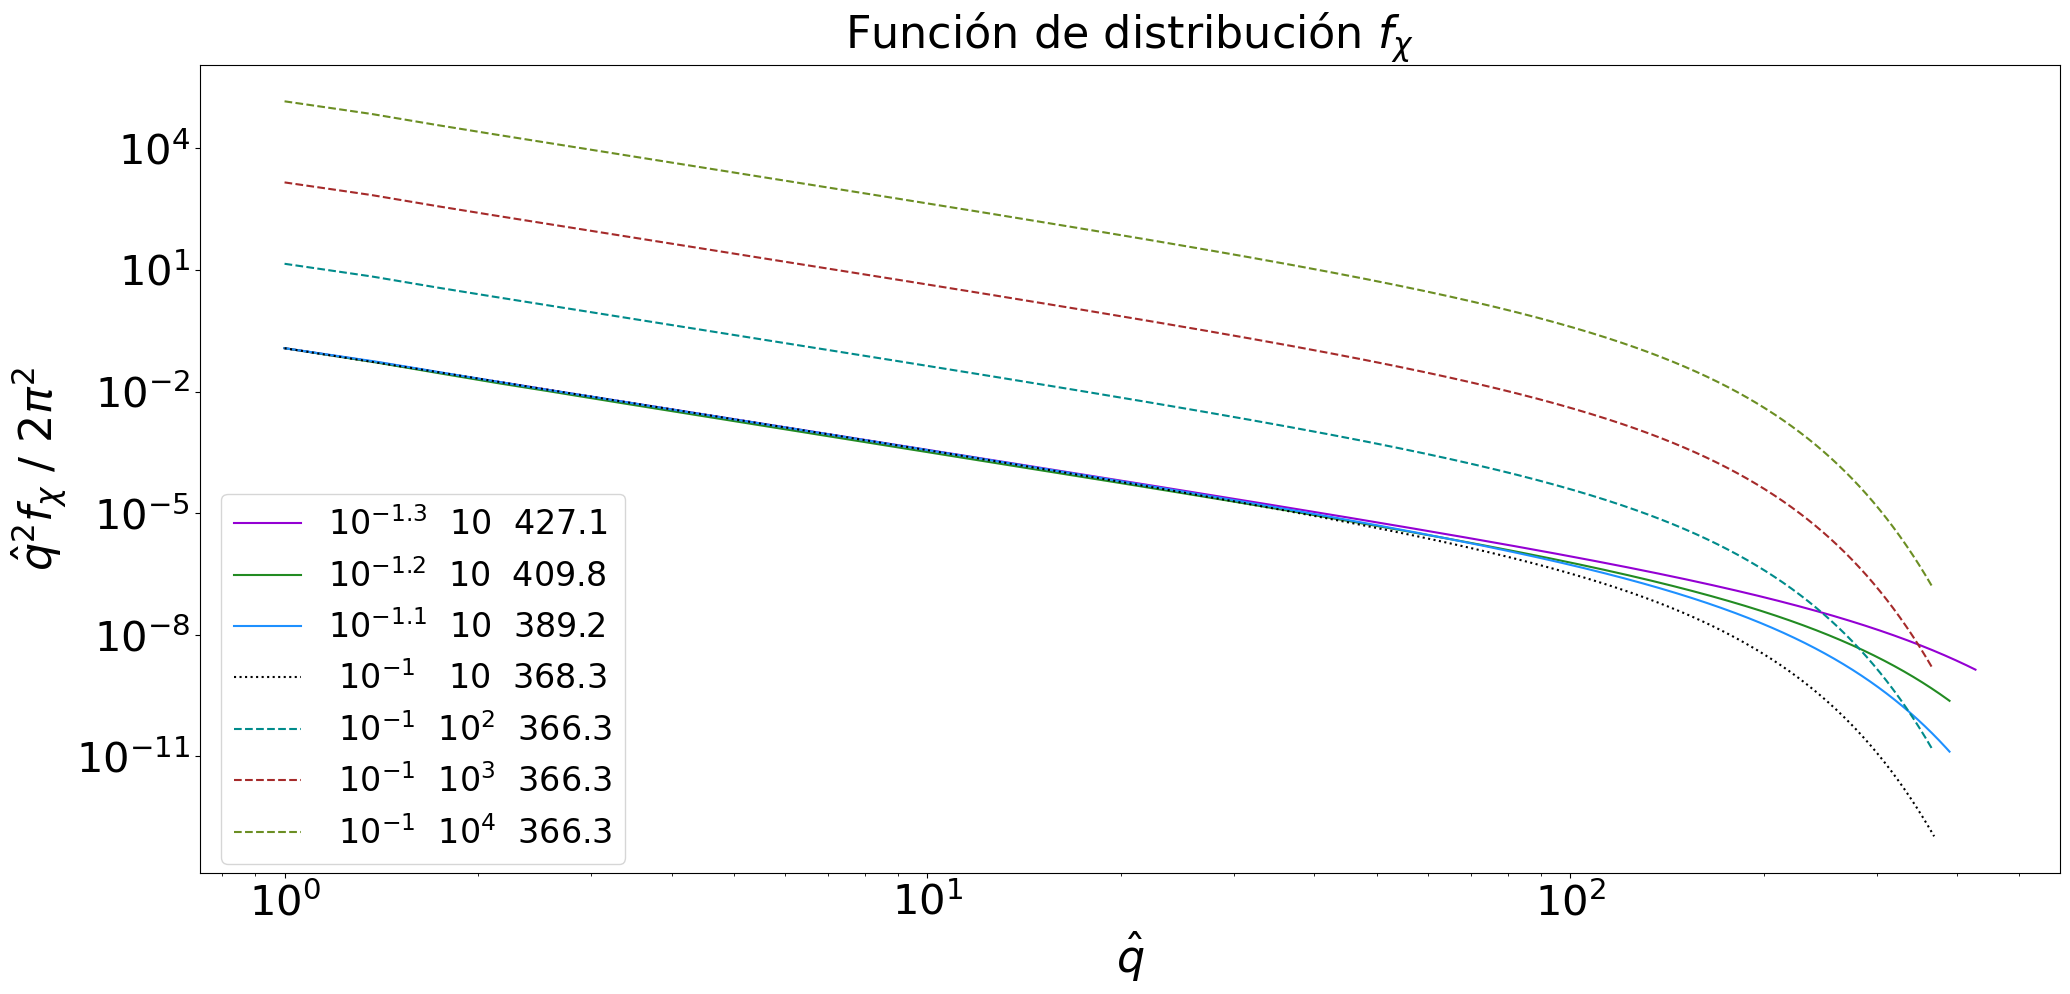

In [298]:
#test_solo1 = soloi(0.0001 * m_phi_reh,(10**1)*lambdaa, 10**(-1))
#test_solo2 = soloi(0.0001 * m_phi_reh,(10**1)*lambdaa, 10**(-1.1))
#test_solo3 = soloi(0.0001 * m_phi_reh,(10**1)*lambdaa, 10**(-1.2))
#test_solo4 = soloi(0.0001 * m_phi_reh,(10**1)*lambdaa, 10**(-1.3))
#test_solo5 = soloi(0.0001 * m_phi_reh,(10**1)*lambdaa, 10**(-1))
#test_solo6 = soloi(0.0001 * m_phi_reh,(10**2)*lambdaa, 10**(-1))
#test_solo7 = soloi(0.0001 * m_phi_reh,(10**3)*lambdaa, 10**(-1))
#test_solo8 = soloi(0.0001 * m_phi_reh,(10**4)*lambdaa, 10**(-1))
#test_solo9 = soloi(0.0001 * m_phi_reh,0, 10**(-1))
#test_solo10 = soloi(0.0001 * m_phi_reh, (10**-1)*lambdaa, 10**(-1))
#test_solo11 = soloi(0.0001 * m_phi_reh, (10**-2)*lambdaa, 10**(-1))
#test_solo12 = soloi(0.0001 * m_phi_reh, (10**-3)*lambdaa, 10**(-1))

import pickle

# Guardar todos los resultados
resultados = {
    'test_solo1': test_solo1,
    'test_solo2': test_solo2,
    'test_solo3': test_solo3,
    'test_solo4': test_solo4,
    'test_solo5': test_solo5,
    'test_solo6': test_solo6,
    'test_solo7': test_solo7,
    'test_solo8': test_solo8,
    'test_solo9': test_solo9,
    'test_solo10': test_solo10,
    'test_solo11': test_solo11,
    'test_solo12': test_solo12
}

with open("resultados_soloi.pkl", "wb") as f:
    pickle.dump(resultados, f)

#print(test_solo1)

#$f_\chi$ at $a(t)/a_{{end}}$ = {test_solo1[3][0][p]:.2f}

plt.figure(figsize = (24, 10.5))
p = -1


plt.plot(test_solo4[1], (test_solo4[1]**2) * test_solo4[0][p, :]/(2*np.pi**2), color = 'darkviolet', 
         ls = 'solid', label = rf'$10^{{-1.3}}$  $10$  {test_solo4[3][0][p]:.1f}')

plt.plot(test_solo2[1], (test_solo3[1]**2) * test_solo3[0][p, :]/(2*np.pi**2), color = 'forestgreen', 
         ls = 'solid', label = rf'$10^{{-1.2}}$  $10$  {test_solo3[3][0][p]:.1f}')

plt.plot(test_solo2[1], (test_solo2[1]**2) * test_solo2[0][p, :]/(2*np.pi**2), color = 'dodgerblue', 
         ls = 'solid', label = rf'$10^{{-1.1}}$  $10$  {test_solo2[3][0][p]:.1f}')

plt.plot(test_solo1[1], (test_solo1[1]**2) * test_solo1[0][p, :]/(2*np.pi**2), color = 'black', 
         ls = 'dotted', label = rf' $10^{{-1}}$   $10$  {test_solo1[3][0][p]:.1f}')

plt.plot(test_solo6[1], (test_solo6[1]**2) * test_solo6[0][p, :]/(2*np.pi**2), color = 'darkcyan', 
         ls = 'dashed', label = rf' $10^{{-1}}$  $10^{{2}}$  {test_solo6[3][0][p]:.1f}')

plt.plot(test_solo7[1], (test_solo7[1]**2) * test_solo7[0][p, :]/(2*np.pi**2), color = 'brown', 
         ls = 'dashed', label = rf' $10^{{-1}}$  $10^{{3}}$  {test_solo7[3][0][p]:.1f}')

plt.plot(test_solo8[1], (test_solo8[1]**2) * test_solo8[0][p, :]/(2*np.pi**2), color = 'olivedrab', 
         ls = 'dashed', label = rf' $10^{{-1}}$  $10^{{4}}$  {test_solo8[3][0][p]:.1f}')

plt.title(rf'Función de distribución $f_\chi$', size = 32)
plt.xlabel(r'$ \hat{q} $', size = 32)
plt.ylabel(r'$ \hat{q}^2 f_\chi \ /\ 2\pi^2$', size = 32)
plt.legend(fontsize=24, bbox_to_anchor=(0.12, 0.49), loc='upper center')
#plt.grid()
plt.tick_params(axis='x', labelsize=30)  # Adjust x-axis tick label size
plt.tick_params(axis='y', labelsize=30)  # Adjust y-axis tick label size
plt.yscale('log')
plt.xscale('log')

plt.savefig('comparacion.png')
plt.show()
#print(a_norm_filt[-1])
#print(test_solo1)
#print(test_corrección)

In [268]:


#test_solo1 = soloi(0.0001 * m_phi_reh,(10**1)*lambdaa, 10**(-1))
n_chi = []
lambdaa = 2.5e-10
sigma = (10**1) * lambdaa
a_norm_reh_t = test_solo1[3][1]
rho_phi_reh_t = test_solo1[5][1]
rho_psi_reh_t = test_solo1[6][1]
q_array = test_solo1[1]
solucion = test_solo1[0] #filas: tiempo, columnas: momento #


for i, t_val in enumerate(t_nuevo):
    if t_val < t_end:
        n_chi.append(0.)
    elif t_val >= t_end:
        prefactor_1 = (1/(2*np.pi**2)) *  (lambdaa**(3/2)) * m_phi_reh**3 
        prefactor_2 = 1 / a_norm_reh_t(t_val)**3

        integrando_val = (q_array**2) * solucion[i, :]
        integral_val = np.trapz(integrando_val, q_array)

        resultado_val = prefactor_1 * prefactor_2 * integral_val
        n_chi.append(integral_val)

n_chi = np.array(n_chi)

rho_chi = []

for i, t_val in enumerate(t_nuevo):
    if t_val < t_end:
        rho_chi.append(0.)
    elif t_val >= t_end:
        prefactor_11 = (1/(2*np.pi**2)) *  (lambdaa**2) * m_phi_reh**4
        prefactor_22 = 1 / a_norm_reh_t(t_val)**3
        integrando_val = (q_array**2) * solucion[i, :] * np.sqrt( q_array**2 + (a_norm_reh_t(t_val)**2) * ( (5.23085e-21)**2 / ((m_phi_reh**2)*lambdaa ) ) )
        integral_val = np.trapz(integrando_val, q_array)

        resultado_val = prefactor_11 * prefactor_22 * integral_val
        rho_chi.append(resultado_val)

rho_chi = np.array(rho_chi)
        


In [290]:
rho_chi_t = scipy.interpolate.interp1d(t_nuevo, rho_chi)
n_chi_t = scipy.interpolate.interp1d(t_nuevo, n_chi)

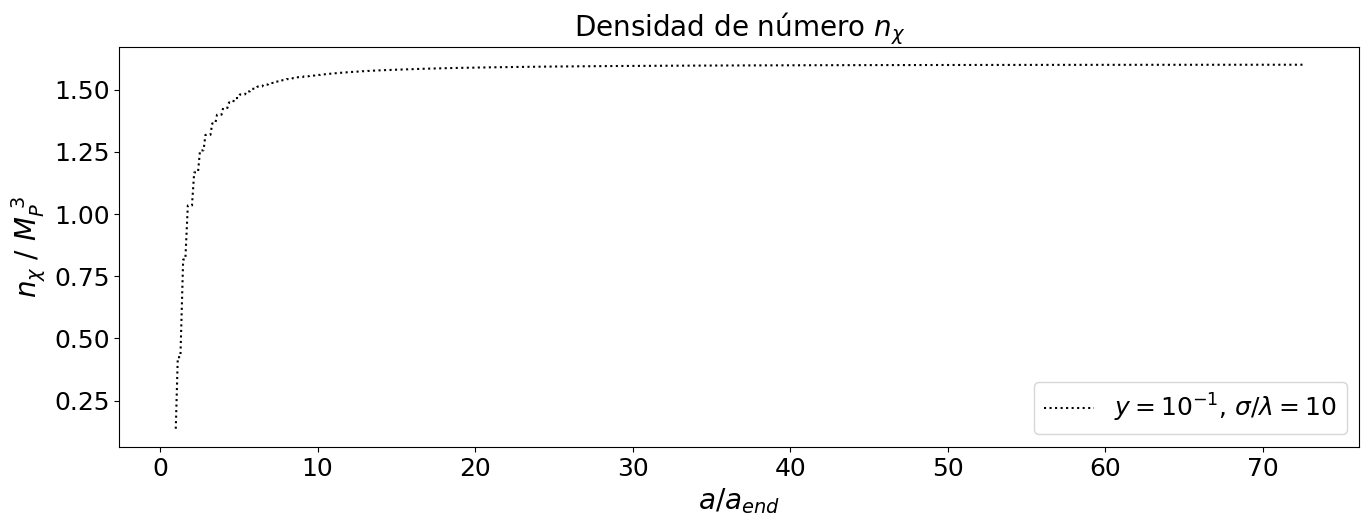

In [297]:
#plt.plot(t[t>=t_end], a_norm_reh_t(t[t>=t_end]))
plt.figure(figsize = (16, 5.2))
plt.plot(a_norm_reh_t(t_nuevo[(t_nuevo >= t_end) & (t_nuevo < 800)]), n_chi_t(t_nuevo[(t_nuevo >= t_end) & (t_nuevo < 800)]), color = 'black', ls = 'dotted', 
         label = r'$ y = 10^{{-1}}$, $\sigma/\lambda = 10$')
plt.title(r'Densidad de número $n_{{\chi}}$', size = 20)
plt.xlabel(r'$a/a_{end}$', size = 20)
plt.ylabel(r'$n_\chi\ /\ M_P^{\ 3}$', size = 20)
plt.tick_params(axis='x', labelsize=18) # Adjust labelsize as needed

# Change the font size of the y-axis tick labels
plt.tick_params(axis='y', labelsize=18) # Adjust labelsize as needed
plt.legend(fontsize = 18)
plt.show()

1916.7181584064592


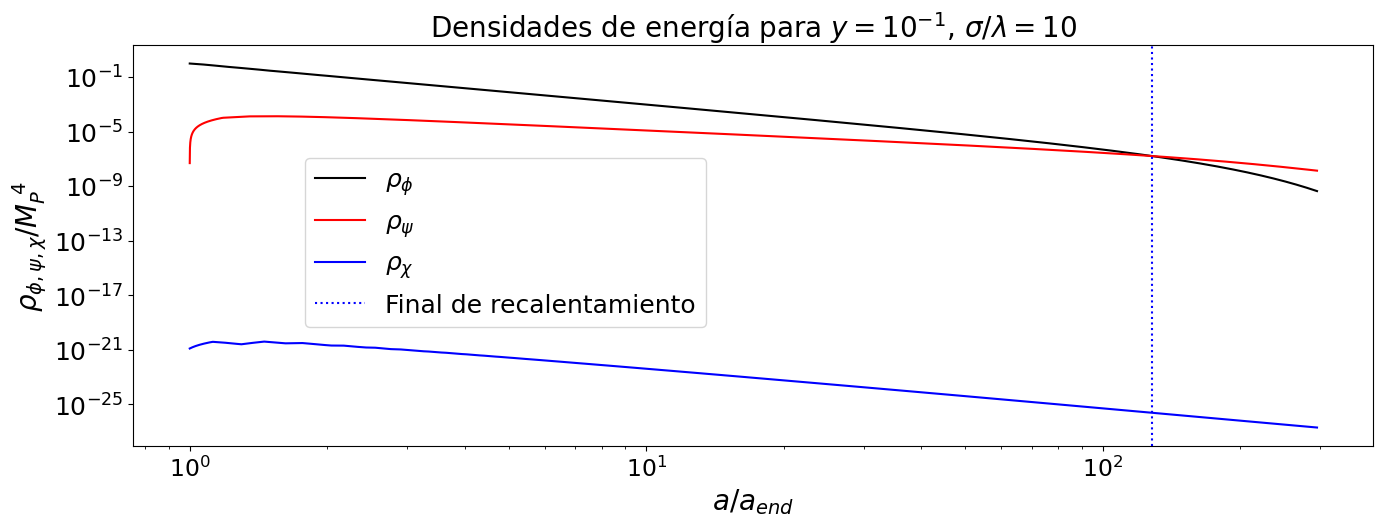

In [294]:
t_nuevo = np.linspace(t_min, t_max, int(np.ceil(int(t_max)*1000)))
t_nuevo = np.array(t_nuevo)


def rho_phi_minus_rho_psi(x):
    return rho_phi_reh_t(x) - rho_psi_reh_t(x)


for i, t_val in enumerate(t_nuevo[t_nuevo >= t_end]):
    if rho_phi_minus_rho_psi(t_val) <= 0:
        t_reh_final = t_val
        break

print(t_reh_final)
plt.figure(figsize = (16, 5.2))
plt.plot(a_norm_reh_t(t_nuevo[(t_nuevo >= t_end) & (t_nuevo < 8000)]), rho_phi_reh_t(t_nuevo[(t_nuevo >= t_end) & (t_nuevo < 8000)]), color = 'black', ls = 'solid', 
         label = r'$\rho_\phi$')
plt.plot(a_norm_reh_t(t_nuevo[(t_nuevo >= t_end) & (t_nuevo < 8000)]), rho_psi_reh_t(t_nuevo[(t_nuevo >= t_end) & (t_nuevo < 8000)]), color = 'red', ls = 'solid', 
         label = r'$\rho_\psi$')
plt.plot(a_norm_reh_t(t_nuevo[(t_nuevo >= t_end) & (t_nuevo < 8000)]), rho_chi_t(t_nuevo[(t_nuevo >= t_end) & (t_nuevo < 8000)]), color = 'blue', ls = 'solid', 
         label = r'$\rho_\chi$')
plt.axvline(x = a_norm_reh_t(t_reh_final), color = 'blue', linestyle = 'dotted', label = 'Final de recalentamiento')
plt.title(r'Densidades de energía para $y = 10^{{-1}}$, $\sigma/\lambda = 10$', size = 20)
plt.xlabel(r'$a/a_{end}$', size = 20)
plt.ylabel(r'$\rho_{\phi, \psi, \chi}/M_P^{{\ 4}}$', size = 20)
plt.yscale('log')
plt.xscale('log')
plt.tick_params(axis='x', labelsize=17) # Adjust labelsize as needed

# Change the font size of the y-axis tick labels
plt.tick_params(axis='y', labelsize=18) # Adjust labelsize as needed
plt.legend(fontsize = 18, bbox_to_anchor=(0.3, 0.75), loc='upper center')
plt.show()

In [ ]:
print(rho_psi_reh_t)

[0.00000000e+00 1.15243939e-04 1.32359142e-04 ... 5.81595916e-09
 5.81549866e-09 5.81503821e-09]


In [ ]:
# Elegir un tiempo físico específico (no un índice)
tiempo_comun = 100.0  # Por ejemplo, t = 100

plt.figure(figsize=(14, 12))

# Para cada test_solo, encontrar el índice más cercano al tiempo común
idx1 = np.argmin(np.abs(test_solo1[2] - tiempo_comun))  # test_solo1[2] es t_submesh
idx2 = np.argmin(np.abs(test_solo2[2] - tiempo_comun))
idx3 = np.argmin(np.abs(test_solo3[2] - tiempo_comun))
idx4 = np.argmin(np.abs(test_solo4[2] - tiempo_comun))
idx6 = np.argmin(np.abs(test_solo6[2] - tiempo_comun))
idx7 = np.argmin(np.abs(test_solo7[2] - tiempo_comun))
idx8 = np.argmin(np.abs(test_solo8[2] - tiempo_comun))

plt.plot(test_solo2[1], (test_solo2[1]**2) * test_solo2[0][idx2, :]/(2*np.pi**2), 
         color='dodgerblue', ls='solid', label=rf'$y = 10^{{-1.1}}$, $\sigma = 10\lambda$')

plt.plot(test_solo3[1], (test_solo3[1]**2) * test_solo3[0][idx3, :]/(2*np.pi**2), 
         color='forestgreen', ls='solid', label=rf'$y = 10^{{-1.2}}$, $\sigma = 10\lambda$')

plt.plot(test_solo4[1], (test_solo4[1]**2) * test_solo4[0][idx4, :]/(2*np.pi**2), 
         color='darkviolet', ls='solid', label=rf'$y = 10^{{-1.3}}$, $\sigma = 10\lambda$')

plt.plot(test_solo1[1], (test_solo1[1]**2) * test_solo1[0][idx1, :]/(2*np.pi**2), 
         color='black', ls='dotted', label=rf'$y = 10^{{-1}}$, $\sigma = 10\lambda$')

plt.plot(test_solo6[1], (test_solo6[1]**2) * test_solo6[0][idx6, :]/(2*np.pi**2), 
         color='darkcyan', ls='dashed', label=rf'$y = 10^{{-1}}$, $\sigma = 10^{{2}}\lambda$')

plt.plot(test_solo7[1], (test_solo7[1]**2) * test_solo7[0][idx7, :]/(2*np.pi**2), 
         color='brown', ls='dashed', label=rf'$y = 10^{{-1}}$, $\sigma = 10^{{3}}\lambda$')

plt.plot(test_solo8[1], (test_solo8[1]**2) * test_solo8[0][idx8, :]/(2*np.pi**2), 
         color='olivedrab', ls='dashed', label=rf'$y = 10^{{-1}}$, $\sigma = 10^{{4}}\lambda$')

plt.title(rf'Phase space distribution $f_\chi$ at $t = {tiempo_comun}$', size=20)
plt.xlabel(r'$ \frac{q}{a_{end} m_\phi} $', size=17)
plt.ylabel(r'$ (\frac{q}{a_{end} m_\phi})^2 f_\chi \ /\ 2\pi^2$', size=16)
plt.legend(fontsize=14)
plt.grid()
plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)
plt.yscale('log')
plt.xscale('log')

plt.savefig('comparacion_mismo_tiempo.png')
plt.show()

In [ ]:
##test_solo5 = soloi(0.0001 * m_phi_reh,(10**1)*lambdaa, 10**(-1))
##test_solo6 = soloi(0.0001 * m_phi_reh,(10**2)*lambdaa, 10**(-1))
##test_solo7 = soloi(0.0001 * m_phi_reh,(10**3)*lambdaa, 10**(-1))
##test_solo8 = soloi(0.0001 * m_phi_reh,(10**4)*lambdaa, 10**(-1))
#test_solo2 = soloi((10**4)*lambdaa, 10**(-6))
#test_solo3 = soloi((10**4)*lambdaa, 10**(-7))
#test_solo4 = soloi((10**4)*lambdaa, 10**(-8))

#print(test_solo1)



plt.figure(figsize = (14, 12))
p = -1
p2 = -100
plt.plot(test_solo5[1], (test_solo5[1]**2) * test_solo5[0][p, :]/(2*np.pi**2), color = 'black', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[p]:.2f}, $y = 10^{{-1}}$, $\sigma = 10^{{1}}\lambda$')

plt.plot(test_solo6[1], (test_solo6[1]**2) * test_solo6[0][p, :]/(2*np.pi**2), color = 'black', ls = 'dashed', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {test_solo6[3][0][p]:.2f}, $y = 10^{{-1}}$, $\sigma = 10^{{2}}\lambda$')

plt.plot(test_solo7[1], (test_solo7[1]**2) * test_solo7[0][p, :]/(2*np.pi**2), color = 'black', ls = 'dashed', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {test_solo7[3][0][p]:.2f}, $y = 10^{{-1}}$, $\sigma = 10^{{3}}\lambda$')

plt.plot(test_solo8[1], (test_solo8[1]**2) * test_solo8[0][p, :]/(2*np.pi**2), color = 'black', ls = 'dashed', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {test_solo8[3][0][p]:.2f}, $y = 10^{{-1}}$, $\sigma = 10^{{4}}\lambda$')

plt.title(rf'Phase space distribution $f_\chi$')
plt.xlabel(r'$ \frac{q}{a_{end} m_\phi} $', size = 16)
plt.ylabel(r'$ (\frac{q}{a_{end} m_\phi})^2 f_\chi$', size = 16)
plt.legend()
plt.grid()
plt.yscale('log')
plt.xscale('log')

plt.savefig('comparacion.png')
plt.show()
print(a_norm_filt[-1])
print(test_solo1)
#print(test_corrección)

In [ ]:
def sol_exponencial(x):
    return (1/2) * (  np.exp(2 * x) - 1  )

correccion_expo1 = sol_exponencial(test_solo1[0][:, :])
#correccion_expo2 = sol_exponencial(test_solo2[:, :])
#correccion_expo3 = sol_exponencial(test_solo3[:, :])
#correccion_expo4 = sol_exponencial(test_solo4[:, :])


plt.figure(figsize = (14, 12))
p = -1
p2 = -100
#plt.plot(q2, (q2**2)*test_corrección[p, :], color = 'black', label = rf'Solución corregida. $\sigma = ${1}')
plt.plot(test_solo1[1], (test_solo1[1]**2) * correccion_expo1[p, :]/(2*np.pi**2), color = 'black', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[p]:.2f}, $y = 0$, $\sigma = 10^{{1}}\lambda$')
#plt.plot(q2, (q2**2) * test_solo1[p2, :], color = 'black', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[p2]:.2f}, $y = 0$, $\sigma = 10^{{1}}\lambda$')
#plt.plot(q2, (q2**2) * correccion_expo2[p, :]/(2*np.pi**2), color = 'red', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[p]:.2f}, $y = 0$, $\sigma = 10^{{2}}\lambda$')
#plt.plot(q2, (q2**2) * correccion_expo3[p, :]/(2*np.pi**2), color = 'blue', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[p]:.2f}, $y = 0$, $\sigma = 10^{{3}}\lambda$')
#plt.plot(q2, (q2**2) * correccion_expo4[p, :]/(2*np.pi**2), color = 'orange', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[p]:.2f}, $y = 0$, $\sigma = 10^{{4}}\lambda$')
plt.plot()
#plt.plot(q2, (q2**2) * test_solo[500, :], color = 'blue', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[500]:.2f}')
plt.title(rf'Phase space distribution $f_\chi$')
plt.xlabel(r'$ \frac{q}{a_{end} m_\phi} $', size = 16)
plt.ylabel(r'$ (\frac{q}{a_{end} m_\phi})^2 f_\chi$', size = 16)
plt.legend()
plt.grid()
plt.yscale('log')
#plt.xscale('log')]

plt.savefig('comparacion.png')
plt.show()
print(a_norm_filt[-1])
#print(test_corrección)

In [ ]:
beta(t[t>t_end], 0.001, 2.5e-10, 2.5e-5)

In [ ]:
plt.plot(t, a_norm)
plt.yscale('log')
plt.show()

In [ ]:
#rho_phi = np.array(rho_phi)
#rho_phi_avaraged = np.array(rho_phi_avaraged)
#plt.plot(t[t>t_end], rho_phi_avaraged[t>t_end], color = 'red')
#plt.plot(t[t>t_end], rho_phi[t>t_end], color = 'black')
#plt.yscale('log')
#plt.show()

In [ ]:
data_all_correction = np.load(r'C:\Users\jcarl\Documents\Maestría\Tesis\Boltzmann\f_chi\Remoto\solij_array.npy', allow_pickle=True)
data_all_solo = np.load(r'C:\Users\jcarl\Documents\Maestría\Tesis\Boltzmann\f_chi\Remoto\soloi_array.npy', allow_pickle=True)


data_2_correction = np.load(r'C:\Users\jcarl\Documents\Maestría\Tesis\Boltzmann\f_chi\Remoto\solij_array2.npy', allow_pickle=True)
data_2_solo = np.load(r'C:\Users\jcarl\Documents\Maestría\Tesis\Boltzmann\f_chi\Remoto\soloi_array2.npy', allow_pickle=True)

data_3_correction = np.load(r'C:\Users\jcarl\Documents\Maestría\Tesis\Boltzmann\f_chi\Remoto\solij_array3.npy', allow_pickle=True)
data_3_solo = np.load(r'C:\Users\jcarl\Documents\Maestría\Tesis\Boltzmann\f_chi\Remoto\soloi_array3.npy', allow_pickle=True)

data_4_correction = np.load(r'C:\Users\jcarl\Documents\Maestría\Tesis\Boltzmann\f_chi\Remoto\solij_array4.npy', allow_pickle=True)
data_4_solo = np.load(r'C:\Users\jcarl\Documents\Maestría\Tesis\Boltzmann\f_chi\Remoto\soloi_array4.npy', allow_pickle=True)

In [ ]:
#q2_min = np.min(a_norm_filt)

#q2_max = np.max(a_norm_filt) #Tengo que ver si conviene este q_max
#N2_q = 40

#q2 = np.linspace(q2_min, q2_max, N2_q)

#q2 = np.array(q2)


#plt.plot(q2, (q2**2) * data_4_correction[12][-1,:], color = 'red', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[p]:.2f}, $y = 0$, $\sigma = 10^{{4}}\lambda$')
#plt.plot(q2, (q2**2) * data_4_solo[0][-1,:], color = 'black', ls = 'dashed', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[p]:.2f}, $y = 0$, $\sigma = 10^{{4}}\lambda$')
#plt.plot(q2, (q2**2) * test_solo[500, :], color = 'blue', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[500]:.2f}')
#plt.title(rf'Phase space distribution $f_\chi$')
#plt.xlabel(r'$ \frac{q}{a_{end} m_\phi} $', size = 16)
#plt.ylabel(r'$ (\frac{q}{a_{end} m_\phi})^2 f_\chi$', size = 16)
#plt.legend()
#plt.grid()
#plt.yscale('log')
#plt.xscale('log')
#plt.show()
#print(a_norm_filt[-1])
#print(test_corrección)

In [ ]:
#print(test_corrección)

In [ ]:
#list(range(1,2))

In [ ]:
#def acoples(n):
#    resultado = []
#    for i in range(0, n+1,2):
#        resultado.append(10**(-i))
#    return resultado

#couplings = acoples(2)
#solij_array = np.empty((len(couplings), len(couplings)), dtype=object)
#soloi_array = np.empty(len(couplings), dtype=object)

#count1 = 0
#for i, sigma_val in enumerate(couplings):
#    for j, y_val in enumerate(couplings):
#        print(f'Empezando solución corregida para sigma = {sigma_val:.1e}, y = {y_val:.1e}')
#        temp = sol3ij(sigma_val, y_val)
#        solij_array[i, j] = temp
#        count1 += 1
#        print(f'Resultado guardado ({count1}/{len(couplings)*len(couplings)})')




#count2 = 0
#for i, sigma_val in enumerate(couplings):
#    print(f'Empezando solución sin corregir para sigma = {sigma_val:.1e}')
#    temp = soloi(sigma_val)
#    soloi_array[i] = temp
#    count2 += 1
#    print(f'Resultado guardado ({count2}/{len(couplings)})')




In [ ]:
#np.save('solij_array.npy', solij_array)
#np.save('soloi_array.npy', soloi_array)

In [ ]:
#plt.figure(figsize = (12, 12))
#p = -1
#b = -1
#c = 1

#plt.plot(q2, (q2**2)*solij_array[b, c][p, :], color = 'black', label = rf'Solución corregida. $\sigma = ${1}')
##plt.plot(q2, (q2**2) * soloi_array[b][p, :], color = 'red', ls = 'dotted', label = 'Solución con corrección')
##plt.title(rf'$a(t)/a_{{end}}$ = {a_norm[a]:.2f}')
#plt.xlabel(r'$ \frac{q}{a_{end} m_\phi} $', size =15 )
#plt.ylabel(r'$ (\frac{q}{a_{end} m_\phi})^2 f_\chi$', size = 15)
#plt.legend()
#plt.grid()
#plt.yscale('log')
#plt.xscale('log')

#plt.savefig('comparacion.png')
#plt.show()

In [ ]:
#plt.figure(figsize = (12, 12))
#a = -1

#plt.plot(q2, (q2**2)*sol66[a, :], color = 'black', label = rf'Solución corregida. $\sigma = ${a6}')
#plt.plot(q2, (q2**2) * solo6[a, :], color = 'red', ls = 'dotted', label = 'Solución con corrección')
#plt.title(rf'$a(t)/a_{{end}}$ = {a_norm[a]:.2f}')
#plt.xlabel(r'$ \frac{q}{a_{end} m_\phi} $', size =15 )
#plt.ylabel(r'$ (\frac{q}{a_{end} m_\phi})^2 f_\chi$', size = 15)
#plt.legend()
#plt.grid()
#plt.yscale('log')
#plt.xscale('log')

#plt.savefig('comparacion.png')
#plt.show()

In [ ]:
#diferencia = f_chi_q_1 - f_chi_q_2

#for i in range(len(t)):
#    for j in range(len(q2)):
#        if diferencia[i, j] != 0.:
#            print('Algo está bien')
#            print(f'La ubicación es i = {i}, j = {j}, diferencia = {diferencia[i,j]}')